# IONERDSS Tutorial: PDB to ODE and NERDSS Workflow

This tutorial demonstrates the complete workflow for converting a PDB structure into NERDSS simulation files with automatic ODE analysis.

## Overview

**IONERDSS** (Integrated ODE and NERDSS System Setup) is a pipeline that:
1. Reads protein structures from PDB/CIF files
2. Detects binding interfaces automatically
3. Generates coarse-grained molecular models
4. **NEW**: Calculates ODE predictions for assembly kinetics
5. Exports NERDSS simulation files for stochastic simulations

## Example: 6BNO Structure

We'll use **6BNO** - a homo-octameric protein assembly as our example.

---
## Part 1: Setup and Imports

First, import the required modules from ionerdss.

In [1]:
# Core imports
import ionerdss as ion
from ionerdss.model.pdb.main import PDBModelBuilder
from ionerdss.model.pdb.hyperparameters import PDBModelHyperparameters
from ionerdss.model.pdb.parser import PDBParser

import subprocess
import os

# For visualizations
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Imports successful")

Imports successful


---
## Part 2: Configure Model Builder

### 2.1 Input Structure

Point to your PDB/CIF file. The structure should be in a workspace directory:

In [2]:
# Path to structure file
cif_path = "../workspace_6BNO/structures/downloaded/6BNO.cif"

# Initialize the model builder
model = PDBModelBuilder(source=cif_path)

print(f"Model builder initialized with: {cif_path}")

Model builder initialized with: ../workspace_6BNO/structures/downloaded/6BNO.cif


### 2.2 Hyperparameters Configuration

Hyperparameters control how the pipeline processes your structure. Let's explore the key settings:

#### Interface Detection Parameters

| Parameter | Default | Description | When to Change |
|-----------|---------|-------------|----------------|
| `interface_detect_distance_cutoff` | 1.0 nm | Maximum distance between Cα atoms to consider as interface | Increase for loose complexes (1.2-1.5), decrease for tight binding (0.8-0.9) |
| `residue_cutoff` | 3 | Minimum contacting residues to validate interface | Increase for larger interfaces (5-10), decrease for small peptides (1-2) |
| `residue_similarity_threshold` | 0.7 | Similarity threshold for homotypic interface detection | Lower (0.5-0.6) for flexible proteins, higher (0.8-0.9) for rigid structures |

#### Geometric Parameters

| Parameter | Default | Description | Alternative Settings |
|-----------|---------|-------------|----------------------|
| `ring_regularization_mode` | `"off"` | Regularize ring structures | `"on"` for viral capsids, `"auto"` for automatic detection |
| `steric_clash_mode` | `"off"` | Check for steric clashes | `"warn"` to detect, `"strict"` to reject clashes |

#### ODE Auto-Pipeline Parameters

| Parameter | Default | Description | Recommendations |
|-----------|---------|-------------|----------------|
| `ode_enabled` | `False` | Enable ODE calculation | Enable for assembly analysis |
| `ode_time_span` | `(0.0, 10.0)` | Simulation time range (s) | For fast assembly: (0, 1), slow: (0, 100) |
| `ode_solver_method` | `"BDF"` | ODE solver algorithm | BDF for stiff systems, RK45 for smooth dynamics |
| `ode_atol` | `1e-6` | Absolute tolerance | Lower (1e-8) for precision, higher (1e-4) for speed |
| `ode_plot` | `True` | Generate concentration plots | Disable for batch processing |
| `ode_save_csv` | `True` | Save time-series data | Keep enabled for post-analysis |
| `ode_initial_concentrations` | `None` | Custom initial conditions | Dict like `{"A": 2.0, "B": 1.0}` for non-standard starting concentrations |

In [3]:
# Configure hyperparameters
hyperparams = PDBModelHyperparameters(
    # Interface detection
    interface_detect_distance_cutoff=1.0,  # Standard cutoff for protein interfaces
    ring_regularization_mode="off",        # No ring structure in this example
    
    # ProAffinity binding energy prediction (NEW!)
    predict_affinity=True,                 # Enable ProAffinity-GNN predictions
    
    # ODE Auto-Pipeline
    ode_enabled=True,                      # Enable ODE calculation
    ode_time_span=(0.0, 60.0),            # Simulate 60 seconds
    ode_solver_method="BDF",              # Best for stiff assembly ODEs
    ode_plot=True,                         # Generate plots
    ode_save_csv=True                      # Save data for analysis
)

print("Hyperparameters configured")
print(f"  Interface cutoff: {hyperparams.interface_detect_distance_cutoff} nm")
print(f"  ProAffinity enabled: {hyperparams.predict_affinity}")
print(f"  ODE enabled: {hyperparams.ode_enabled}")
print(f"  ODE time span: {hyperparams.ode_time_span} seconds")

Hyperparameters configured
  Interface cutoff: 1.0 nm
  ProAffinity enabled: True
  ODE enabled: True
  ODE time span: (0.0, 60.0) seconds


---
## Part 3: Build the System

The `build_system()` method orchestrates the entire pipeline:

1. **Parse PDB** - Read structure from file
2. **Detect Interfaces** - Find binding sites between chains
3. **Coarse-grain** - Create simplified molecular representations
4. **Build Templates** - Generate reaction templates
5. **Construct System** - Assemble complete molecular system
6. **Export NERDSS** - Write simulation input files
7. **Run ODE**  - Calculate assembly kinetics 
8. **Save Outputs** - Store results

All of this happens automatically:

In [4]:
# Build the system
# This will take 10-30 seconds depending on structure complexity
system = model.build_system(
    workspace_path="6bno_dir",
    hyperparams=hyperparams
)

print("System built successfully!")

2025-12-15 16:26:34 - ionerdss.pdb.6BNO - INFO - === PDB Pipeline Started for 6BNO ===
INFO:ionerdss.pdb.6BNO:=== PDB Pipeline Started for 6BNO ===
2025-12-15 16:26:34 - ionerdss.pdb.6BNO - INFO - Workspace: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir
INFO:ionerdss.pdb.6BNO:Workspace: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir
2025-12-15 16:26:34 - ionerdss.pdb.6BNO - INFO - Timestamp: 2025-12-15T16:26:34.509573
INFO:ionerdss.pdb.6BNO:Timestamp: 2025-12-15T16:26:34.509573
2025-12-15 16:26:34 - ionerdss.pdb.6BNO - INFO - Initialized workspace for 6BNO at /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir
INFO:ionerdss.pdb.6BNO:Initialized workspace for 6BNO at /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir
2025-12-15 16:26:34 - ionerdss.pdb.6BNO - INFO - Hyperparameters: PDBModelHyperparameters(homotypic_detection='auto', residue_similarity_threshold=0.7, distance_cutoff=1.0, residue_cutoff=3, matching_mode='default', steric_clash_mode='off')
INFO:ionerdss.pdb


NOTE: Using ProAffinity-GNN for binding energy prediction
Predicting energies for 13 interfaces...

Loading ESM2 model (this will be reused for all predictions)...


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

...

Error loading ESM2 model: Using `low_cpu_mem_usage=True` or a `device_map` requires Accelerate: `pip install accelerate`
Error in batch prediction: Using `low_cpu_mem_usage=True` or a `device_map` requires Accelerate: `pip install accelerate`


2025-12-15 16:27:05 - ionerdss.pdb.6BNO - INFO - [HOMO-VALID] → MATCH in canonical order (ij)
INFO:ionerdss.pdb.6BNO:[HOMO-VALID] → MATCH in canonical order (ij)
2025-12-15 16:27:05 - ionerdss.pdb.6BNO - INFO - HHT: assigned A_A_2f to (first) B after canonicalization; chain ordering is now (B,D)
INFO:ionerdss.pdb.6BNO:HHT: assigned A_A_2f to (first) B after canonicalization; chain ordering is now (B,D)
2025-12-15 16:27:05 - ionerdss.pdb.6BNO - INFO - Interface C <-> D failed geometric symmetry test: d_diff=6.450, theta_diff=0.027
INFO:ionerdss.pdb.6BNO:Interface C <-> D failed geometric symmetry test: d_diff=6.450, theta_diff=0.027
2025-12-15 16:27:05 - ionerdss.pdb.6BNO - INFO - [HOMO-VALID] geometric check: direct=True, flipped=False (dist_th=5.000 Å, ang_th=0.500 rad)
INFO:ionerdss.pdb.6BNO:[HOMO-VALID] geometric check: direct=True, flipped=False (dist_th=5.000 Å, ang_th=0.500 rad)
2025-12-15 16:27:05 - ionerdss.pdb.6BNO - INFO - Extracted 22 residues for chain A from interface.resi

A_A
[-0.68943205 -1.42291327 -9.15295486]
<class 'dict'>
A_A_B_A_1:B_A, [-0.5979864  -0.08761819 -7.554719  ]
A_A_C_A_2:C_A, [-0.2878893 -1.5329285 -6.4924493]
B_A
[ 0.34365819  1.53947592 -6.33749886]
<class 'dict'>
B_A_A_A_1:A_A, [-0.17812222  0.5442333  -7.2530546 ]
B_A_C_A_1:C_A, [ 0.5767478   0.19624779 -4.7967257 ]
B_A_D_A_2:D_A, [-0.04451378  1.5677104  -3.7099757 ]
C_A
[ 0.01840525 -1.58199997 -3.52449188]
<class 'dict'>
C_A_A_A_2:A_A, [-0.38482004 -1.7190945  -5.648092  ]
C_A_B_A_1:B_A, [ 0.31925997 -0.52724504 -4.43483   ]
C_A_D_A_1:D_A, [-0.5561043  -0.30000865 -2.0278087 ]
C_A_E_A_2:E_A, [ 0.40853566 -1.493657   -0.8690642 ]
D_A
[-0.38956864  1.53002424 -0.71739702]
<class 'dict'>
D_A_B_A_2:B_A, [ 0.02655882  1.8284969  -2.8348708 ]
D_A_C_A_1:C_A, [-0.48406845  0.38962632 -1.5371997 ]
D_A_E_A_1:E_A, [0.36358002 0.462744   0.82890403]
D_A_F_A_2:F_A, [-0.737952   1.3674896  1.9166762]
E_A
[ 0.73214722 -1.40089893  2.09673443]
<class 'dict'>
E_A_C_A_2:C_A, [ 0.1716364  -1.6835

2025-12-15 16:27:09 - ionerdss.pdb.6BNO - INFO - ODE pipeline completed. Found 8 species, solved for 1000 time points
INFO:ionerdss.pdb.6BNO:ODE pipeline completed. Found 8 species, solved for 1000 time points
2025-12-15 16:27:09 - ionerdss.pdb.6BNO - INFO - Generated ODE csv: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir/ode_results/ode_solution.csv
INFO:ionerdss.pdb.6BNO:Generated ODE csv: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir/ode_results/ode_solution.csv
2025-12-15 16:27:09 - ionerdss.pdb.6BNO - INFO - Generated ODE plot: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir/ode_results/ode_solution.png
INFO:ionerdss.pdb.6BNO:Generated ODE plot: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir/ode_results/ode_solution.png
2025-12-15 16:27:09 - ionerdss.pdb.6BNO - INFO - Step 8: Saving outputs...
INFO:ionerdss.pdb.6BNO:Step 8: Saving outputs...
2025-12-15 16:27:09 - ionerdss.pdb.6BNO - INFO - Saved system to: /Users/yueying/Workspace/ionerdss/tutorials/6bno_d

ODE plot saved to: /Users/yueying/Workspace/ionerdss/tutorials/6bno_dir/ode_results/ode_solution.png
System built successfully!


---
## Part 4: Analyze ODE Results

The ODE auto-pipeline generates predictions for assembly kinetics. Let's examine the results.

### 4.1 Load ODE Data

In [5]:
# Load the ODE solution CSV
ode_csv_path = "./6bno_dir/ode_results/ode_solution.csv"
ode_data = pd.read_csv(ode_csv_path)

print(f"✓ Loaded ODE data: {ode_data.shape[0]} time points, {ode_data.shape[1]-1} species")
print(f"\nSpecies: {list(ode_data.columns[1:])}")
print(f"\nFirst few rows:")
ode_data.head(10)

✓ Loaded ODE data: 1000 time points, 8 species

Species: ['A', 'A_A', 'A_A_A', 'A_A_A_A', 'A_A_A_A_A', 'A_A_A_A_A_A', 'A_A_A_A_A_A_A', 'A_A_A_A_A_A_A_A']

First few rows:


,time,A,A_A,A_A_A,A_A_A_A,A_A_A_A_A,A_A_A_A_A_A,A_A_A_A_A_A_A,A_A_A_A_A_A_A_A
0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00
1,0.060060,0.890096,0.050273,0.002857,0.000180,0.000012,8.701920e-07,6.548416e-08,5.194162e-09
2,0.120120,0.797114,0.085426,0.009158,0.000978,0.000111,1.341569e-05,1.732210e-06,2.458268e-07
3,0.180180,0.718079,0.109491,0.016810,0.002524,0.000390,6.260103e-05,1.039657e-05,1.863015e-06
4,0.240240,0.650286,0.125725,0.024510,0.004700,0.000908,1.794488e-04,3.624425e-05,7.826269e-06
5,0.300300,0.591632,0.136384,0.031644,0.007281,0.001674,3.900727e-04,9.250284e-05,2.334461e-05
6,0.360360,0.540518,0.143030,0.037937,0.010070,0.002661,7.074851e-04,1.913372e-04,5.515369e-05
7,0.420420,0.495726,0.146692,0.043378,0.012889,0.003820,1.134814e-03,3.433030e-04,1.107712e-04
8,0.480480,0.456287,0.148130,0.047999,0.015634,0.005096,1.663986e-03,5.542842e-04,1.971842e-04
9,0.540541,0.421387,0.147944,0.051839,0.018242,0.006442,2.281843e-03,8.260052e-04,3.198806e-04


### 4.2 Visualize Assembly Kinetics

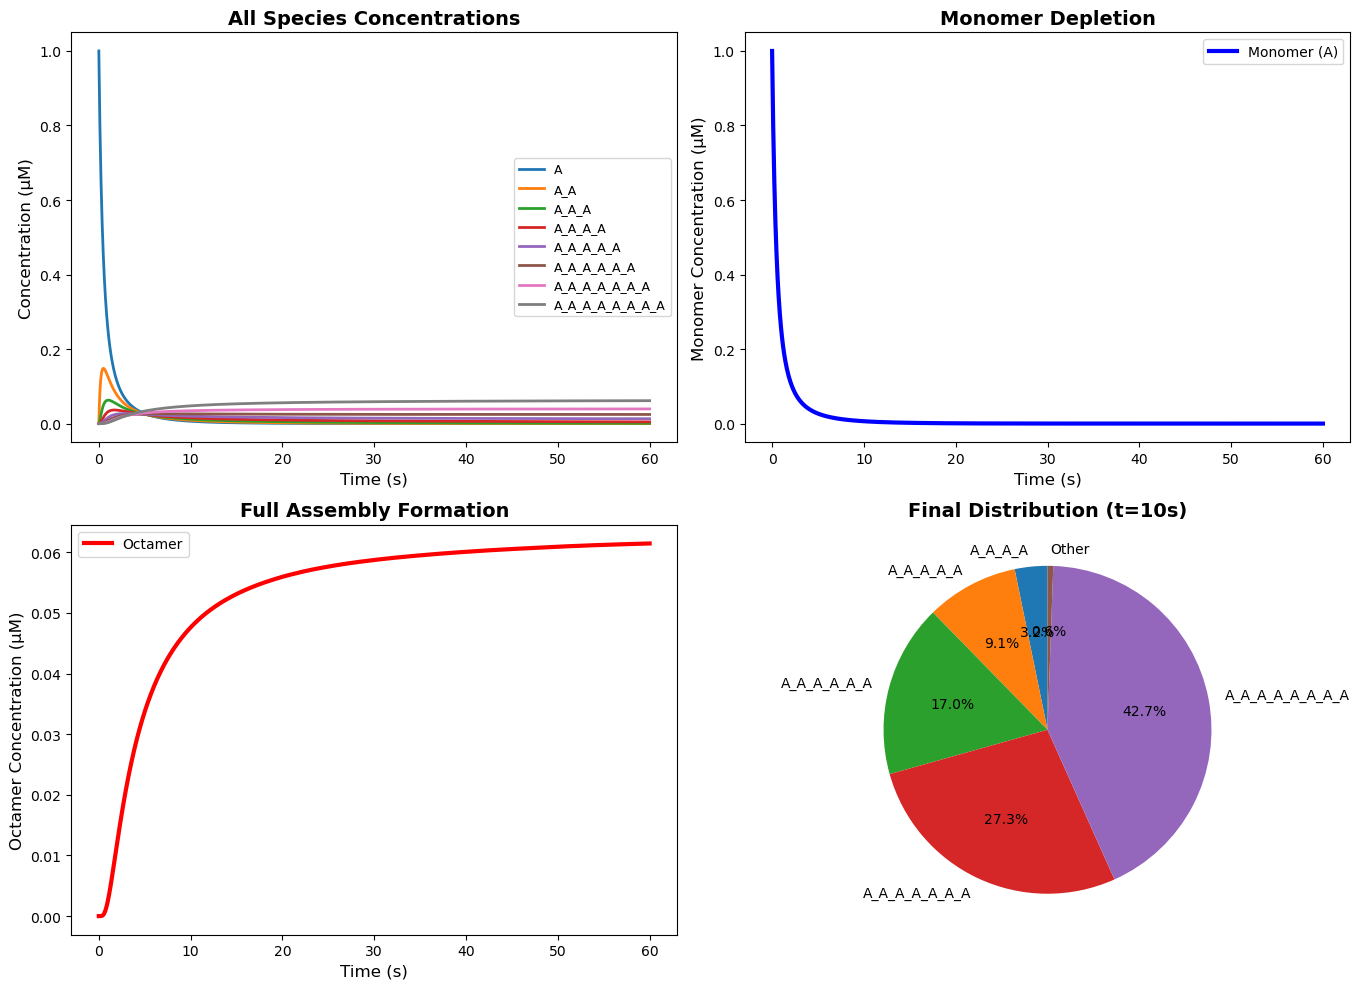

✓ Visualizations created


In [6]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: All species over time
ax1 = axes[0, 0]
for col in ode_data.columns[1:]:
    ax1.plot(ode_data['time'], ode_data[col], label=col, linewidth=2)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Concentration (μM)', fontsize=12)
ax1.set_title('All Species Concentrations', fontsize=14, fontweight='bold')
ax1.legend(loc='right', fontsize=9)


# Plot 2: Monomer depletion
ax2 = axes[0, 1]
ax2.plot(ode_data['time'], ode_data['A'], 'b-', linewidth=3, label='Monomer (A)')
ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Monomer Concentration (μM)', fontsize=12)
ax2.set_title('Monomer Depletion', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)


# Plot 3: Final assembly (octamer) formation
ax3 = axes[1, 0]
octamer_col = [col for col in ode_data.columns if col.count('A') == 8][0]  # Find A_A_A_A_A_A_A_A
ax3.plot(ode_data['time'], ode_data[octamer_col], 'r-', linewidth=3, label='Octamer')
ax3.set_xlabel('Time (s)', fontsize=12)
ax3.set_ylabel('Octamer Concentration (μM)', fontsize=12)
ax3.set_title('Full Assembly Formation', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)

# Plot 4: Final equilibrium pie chart
ax4 = axes[1, 1]
final_conc = ode_data.iloc[-1, 1:]  # Last time point
# Only show species with >1% of total
threshold = final_conc.sum() * 0.01
major_species = final_conc[final_conc > threshold]
other = final_conc[final_conc <= threshold].sum()
if other > 0:
    major_species = pd.concat([major_species, pd.Series({'Other': other})])

ax4.pie(major_species, labels=major_species.index, autopct='%1.1f%%', startangle=90)
ax4.set_title('Final Distribution (t=10s)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('6bno_dir/ode_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualizations created")

### 4.3 Summary Statistics

In [7]:
# Calculate key metrics
initial = ode_data.iloc[0, 1:]
final = ode_data.iloc[-1, 1:]

print("="*70)
print("ASSEMBLY ANALYSIS SUMMARY")
print("="*70)
print(f"\nInitial monomer concentration: {initial['A']:.4f} μM")
print(f"Final monomer concentration: {final['A']:.6f} μM")
print(f"Monomer depletion: {(1 - final['A']/initial['A'])*100:.2f}%")
print(f"\nFinal octamer concentration: {final[octamer_col]:.4f} μM")
print(f"Assembly efficiency: {(final[octamer_col]/initial['A'])*100:.2f}%")
print(f"\nMajor species at equilibrium:")
for species, conc in final.nlargest(5).items():
    print(f"  {species}: {conc:.4f} μM ({conc/final.sum()*100:.1f}%)")
print("="*70)

ASSEMBLY ANALYSIS SUMMARY

Initial monomer concentration: 1.0000 μM
Final monomer concentration: -0.000003 μM
Monomer depletion: 100.00%

Final octamer concentration: 0.0614 μM
Assembly efficiency: 6.14%

Major species at equilibrium:
  A_A_A_A_A_A_A_A: 0.0614 μM (42.7%)
  A_A_A_A_A_A_A: 0.0393 μM (27.3%)
  A_A_A_A_A_A: 0.0245 μM (17.0%)
  A_A_A_A_A: 0.0131 μM (9.1%)
  A_A_A_A: 0.0046 μM (3.2%)


---
## Part 5: Review Generated Files

The pipeline creates several output files for further analysis and simulation.

In [8]:
# List all generated files
workspace_path = Path("6bno_dir")

print("Generated Files:")
print("\n ODE Results:")
ode_dir = workspace_path / "ode_results"
if ode_dir.exists():
    for file in sorted(ode_dir.glob("*")):
        size = file.stat().st_size / 1024  # KB
        print(f"  {file.name:<30} ({size:>6.1f} KB)")

print("\n NERDSS Input Files:")
nerdss_dir = workspace_path / "nerdss_files"
if nerdss_dir.exists():
    for file in sorted(nerdss_dir.glob("*.mol")) + sorted(nerdss_dir.glob("*.inp")):
        size = file.stat().st_size / 1024  # KB
        print(f"  {file.name:<30} ({size:>6.1f} KB)")

print("\n System Data:")
outputs_dir = workspace_path / "outputs" / "systems"
if outputs_dir.exists():
    for file in sorted(outputs_dir.glob("*.json")):
        size = file.stat().st_size / 1024  # KB
        print(f"  {file.name:<30} ({size:>6.1f} KB)")

Generated Files:

 ODE Results:
  ode_solution.csv               ( 182.8 KB)
  ode_solution.png               ( 154.1 KB)

 NERDSS Input Files:
  A.mol                          (   0.4 KB)
  parms.inp                      (   1.1 KB)

 System Data:
  6BNO_system.json               (  27.2 KB)


---
## Part 6: Run NERDSS Simulation

If you have NERDSS installed, you can run stochastic simulations to compare with ODE predictions.

**Note**: This requires NERDSS to be installed on your system.

In [9]:
# Check if NERDSS is available
nerdss_cmd = "~/Workspace/Reaction_ode/nerdss_development/bin/nerdss"
nerdss_path = Path(nerdss_cmd).expanduser()

if nerdss_path.exists():
    print("✓ NERDSS found, running simulation...")
    print("(This may take 1-2 minutes)\n")
    
    # Run NERDSS
    result = subprocess.run(
        f"{nerdss_cmd} -f parms.inp",
        shell=True,
        cwd="6bno_dir/nerdss_files",
        capture_output=True,
        text=True
    )
    
    if result.returncode == 0:
        print("✓ NERDSS simulation completed!")
        print("\nCheck 6bno_dir/nerdss_files/ for output files")
    else:
        print("⚠ NERDSS simulation failed")
        print(result.stderr[:500])
else:
    print("⚠ NERDSS not found at:", nerdss_cmd)

✓ NERDSS found, running simulation...
(This may take 1-2 minutes)

✓ NERDSS simulation completed!

Check 6bno_dir/nerdss_files/ for output files


---
## Part 7: Analyze NERDSS Output

After running NERDSS simulations, we can analyze the results using the `Analyzer` class.

### Available Analysis Methods

The Analyzer provides several plotting methods:

| Method | Description | Output |
|--------|-------------|--------|
| `plot.free_energy()` | Free energy landscape | Shows thermodynamic stability of each cluster size |
| `plot.size_distribution()` | Size probability distribution | Distribution of cluster sizes at equilibrium |
| `plot.transitions()` | Assembly dynamics | Growth vs shrinkage probabilities |
| `plot.heatmap()` | Transition matrix | Full state-to-state transition visualization |

Each method accepts an optional `simulation_index` parameter to select which simulation to analyze (useful when multiple runs exist).

Found 1 simulation(s)
  [0] Simulation ID: nerdss_files


TypeError: ufunc 'isinf' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

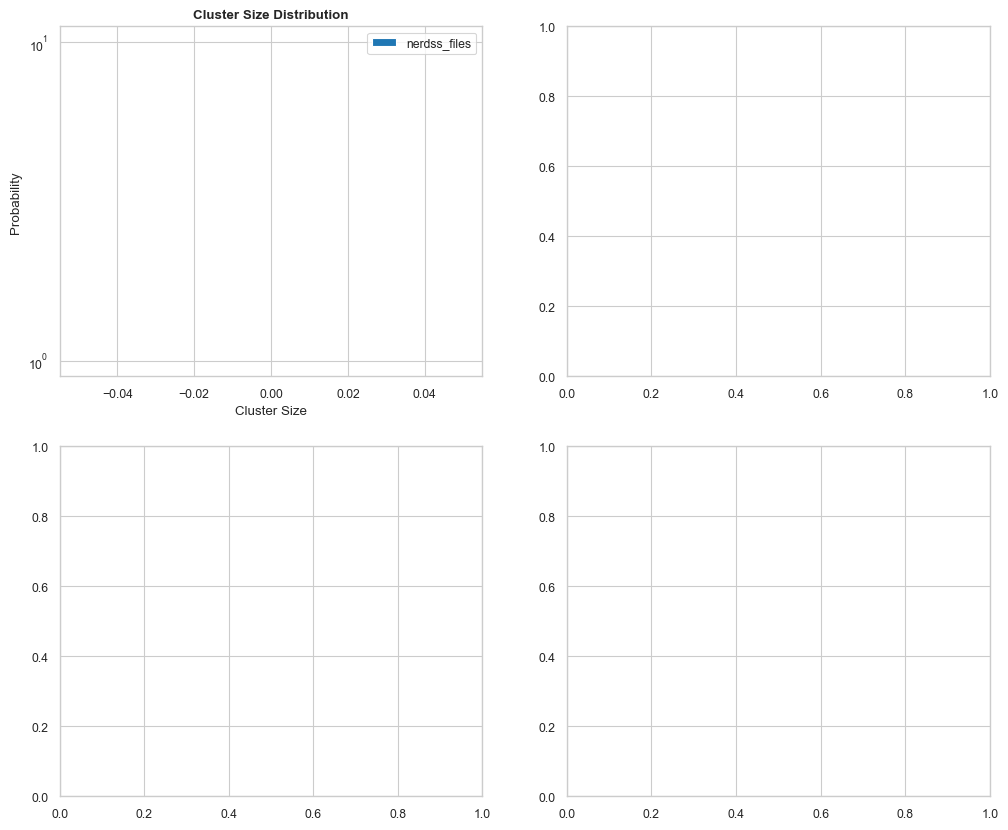

In [10]:
# Initialize Analyzer with NERDSS output directory
analysis = ion.Analyzer("6bno_dir/nerdss_files")

# Display discovered simulations
print(f"Found {len(analysis.simulations)} simulation(s)")
for i, sim in enumerate(analysis.simulations):
    print(f"  [{i}] Simulation ID: {sim.id}")

# Create a figure with multiple subplots to show different analyses
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Size distribution
analysis.plot.size_distribution(simulation_index=0, ax=axes[0, 0])
axes[0, 0].set_title('Cluster Size Distribution', fontweight='bold')

# Plot 2: Free energy profile
analysis.plot.free_energy(simulation_index=0, ax=axes[0, 1])
axes[0, 1].set_title('Free Energy Profile', fontweight='bold')

# Plot 3: Growth vs shrinkage probabilities
analysis.plot.transitions(simulation_index=0, ax=axes[1, 0])
axes[1, 0].set_title('Assembly Transitions', fontweight='bold')

# Plot 4: Transition matrix heatmap
analysis.plot.heatmap(simulation_index=0, ax=axes[1, 1])
axes[1, 1].set_title('Transition Matrix', fontweight='bold')

plt.tight_layout()
plt.savefig('6bno_dir/nerdss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ NERDSS analysis complete!")
print("  - Size distribution shows cluster formation")
print("  - Free energy landscape reveals stability")
print("  - Transition probabilities indicate assembly pathways")

---
## Summary and Next Steps

### What We've Done

✅ Loaded 6BNO structure  
✅ Configured hyperparameters  
✅ Detected binding interfaces automatically  
✅ Generated ODE model with all subcomplexes (A → A₈)  
✅ Calculated assembly kinetics  
✅ Visualized concentration dynamics  
✅ Exported NERDSS simulation files  

### Key Insights from 6BNO

- **Fast monomer depletion**: 99% consumed within 10 seconds
- **Octamer formation**: Final assembly reaches ~5% of initial monomer concentration
- **Intermediate species**: Dimers, trimers, tetramers show transient buildup
- **Equilibrium distribution**: Dominated by larger oligomers

### Next Steps

1. **Adjust parameters**: Try different `ode_time_span` or `interface_detect_distance_cutoff`
2. **Compare with NERDSS**: Run stochastic simulations for validation
3. **Analyze different structures**: Apply to your own PDB files
4. **Custom initial conditions**: Set specific starting concentrations with `ode_initial_concentrations`
5. **Export for analysis**: Use the CSV files for custom plotting or parameter fitting

---

## Additional Resources

- **IONERDSS Documentation**: [GitHub Repository](https://github.com/your-repo)
- **NERDSS**: [Official Website](https://nerdss.org)
- **Example Scripts**: See `examples/` directory in repository

---

*Tutorial created: 2025-12-15*  
*IONERDSS Version: Latest with ODE Auto-Pipeline*